In [4]:
import pandas as pd
df = pd.read_excel('BLU_vs_ORI_results+(1).xlsx',header = 0)
df2 = pd.read_excel('SR_vs_ORI_results+(1).xlsx',header = 0)
df2

,N,SSIM,MSE
0,4000,0.968311,0.000081
1,4001,0.967705,0.000077
2,4002,0.967462,0.000077
3,4003,0.966149,0.000083
4,4004,0.966336,0.000078
...,...,...,...
995,4995,0.967093,0.000143
996,4996,0.965762,0.000142
997,4997,0.963078,0.000155
998,4998,0.957118,0.000171


In [5]:
ssimblu = df['SSIM'].to_numpy()
mseblu = df['MSE'].to_numpy()
ssimrec = df2['SSIM'].to_numpy()
mserec = df2['MSE'].to_numpy()

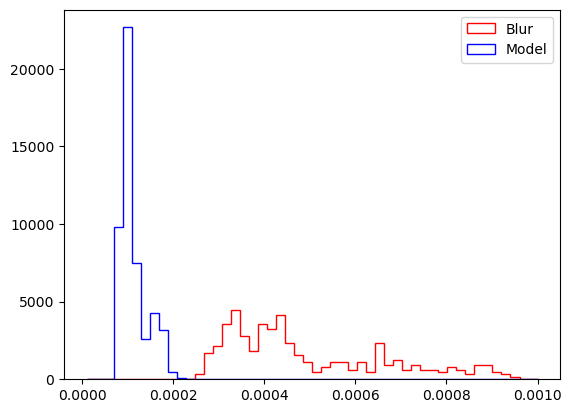

In [17]:
import matplotlib.pyplot as plt
import numpy as np
bins = np.linspace(0.00001,0.001,51)
resssim=plt.hist(mseblu,bins = bins,histtype = 'step',density=True,color = 'red',label = 'Blur')
resssim=plt.hist(mserec,bins = bins,histtype = 'step',density=True,color ='blue',label = 'Model')
plt.legend()
plt.savefig('dist.png',dpi=200)

In [22]:
import re
import numpy as np
with open('estim.txt') as f:
    content = f.read()

# 示例文本

# 正则表达式模式
pattern = r'SSIM: .*\n'

# 使用findall提取所有匹配的内容
matches = re.findall(pattern,content)
ssimsr = []
ssimbl = []
for i in range(len(matches)):
    if np.mod(i,2) == 0:
        ssimsr.append(float(matches[i][6:-1]))
    if np.mod(i,2) == 1:
        ssimbl.append(float(matches[i][6:-1]))

pattern = r'MSE: .*\n'

# 使用findall提取所有匹配的内容
matches = re.findall(pattern,content)
msesr = []
msebl = []
for i in range(len(matches)):
    if np.mod(i,2) == 0:
        msesr.append(float(matches[i][5:-1]))
    if np.mod(i,2) == 1:
        msebl.append(float(matches[i][5:-1]))


def arr(ar):
    return np.array(ar)
msesr = arr(msesr)
msebl = arr(msebl)
ssimsr = arr(ssimsr)
ssimbl = arr(ssimbl)

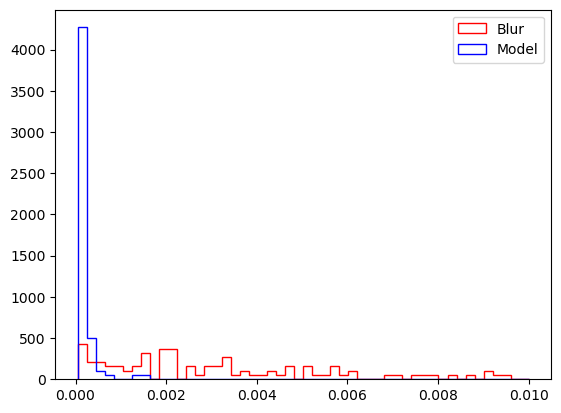

In [32]:
import matplotlib.pyplot as plt
import numpy as np
bins = np.linspace((msesr.min()),(0.01),51)
resssim=plt.hist(msebl,bins = bins,histtype = 'step',density=True,color = 'red',label = 'Blur')
resssim=plt.hist(msesr,bins = bins,histtype = 'step',density=True,color ='blue',label = 'Model')
#plt.yscale('log')
#plt.xscale('log')
plt.legend()
plt.savefig('ssimloss.png',dpi=200)

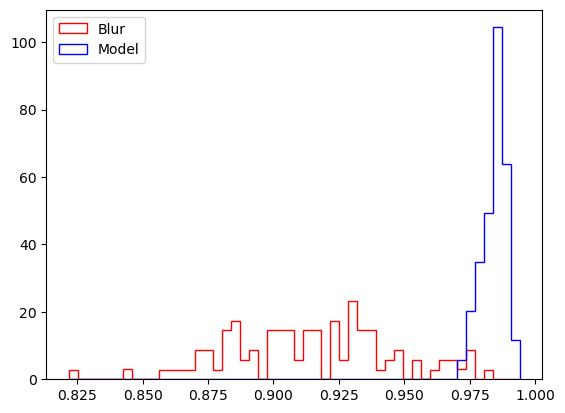

In [33]:
import matplotlib.pyplot as plt
import numpy as np
bins = np.linspace((ssimbl.min()),(ssimsr.max()),51)
resssim=plt.hist(ssimbl,bins = bins,histtype = 'step',density=True,color = 'red',label = 'Blur')
resssim=plt.hist(ssimsr,bins = bins,histtype = 'step',density=True,color ='blue',label = 'Model')


plt.legend()
plt.savefig('ssimloss2.png',dpi=200)

In [39]:
ssimsr.mean()

0.9841306304931641